<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/EfficientNetB0_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Classification using EfficientNet-B0

**Goal:** Train EfficientNet-B0 to classify skin lesion images and visualize training/validation loss and accuracy.

 The project brief specifies the **HAM10000 dataset** and **EfficientNetB0** architecture for skin lesion classification. fileciteturn0file0L2-L6


## 1. What we will do

Our complete pipeline is:

**Dataset → Explore → Train/Validation split → Image preprocessing → EfficientNet-B0 → Train → Plot loss & accuracy → Evaluate**

Understand:

- Is the model learning?
- Is training accuracy improving?
- Is validation accuracy improving?
- Is the model overfitting?
- Is validation loss increasing while training loss decreases?


In [1]:
# Install packages

!pip install -q tensorflow pandas matplotlib scikit-learn pillow


## 2. Get the HAM10000 dataset

### Option A — KaggleHub

If you have Kaggle access configured, the following cell downloads the dataset.

The exact dataset slug can vary between Kaggle copies.


```


In [2]:
# OPTION A: Download from Kaggle using kagglehub
# If this fails because of Kaggle authentication or dataset availability,
# use OPTION B below.

import os

try:
    import kagglehub
    path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print("Dataset downloaded to:", path)
except Exception as e:
    print("KaggleHub download was not successful.")
    print("Use the manual-download option described above.")
    print("Error:", e)


100%|██████████| 5.20G/5.20G [00:50<00:00, 111MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [3]:
# OPTION B: Set this manually if you downloaded HAM10000 yourself.
# Example:
# DATA_DIR = "/content/HAM10000"

DATA_DIR = "/content/HAM10000"

# If using KaggleHub, inspect the downloaded folder and change DATA_DIR accordingly.
print("DATA_DIR:", DATA_DIR)


DATA_DIR: /content/HAM10000


## 3. Import libraries

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 4. Load the metadata

HAM10000 contains a metadata CSV describing the lesion images and their diagnostic class.

We use the metadata to connect each image file with its class label.


In [6]:
DATA_DIR = '/root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2'

# Search for the metadata file automatically

metadata_candidates = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(".csv") and "metadata" in file.lower():
            metadata_candidates.append(os.path.join(root, file))

print("Metadata files found:")
for f in metadata_candidates:
    print(f)

if not metadata_candidates:
    raise FileNotFoundError(
        "HAM10000_metadata.csv was not found. "
        "Check DATA_DIR and your downloaded dataset."
    )

metadata_path = metadata_candidates[0]
df = pd.read_csv(metadata_path)

print("\nShape:", df.shape)
display(df.head())

Metadata files found:
/root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2/HAM10000_metadata.csv

Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 5. Understand the target classes

The target column in HAM10000 is usually called `dx`.

Each image belongs to one of several lesion categories.

We will use the original multi-class labels rather than changing the problem into binary classification.


In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nClass distribution:")
display(df["dx"].value_counts())

print("\nClass names:")
print(sorted(df["dx"].unique()))


Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115



Class names:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


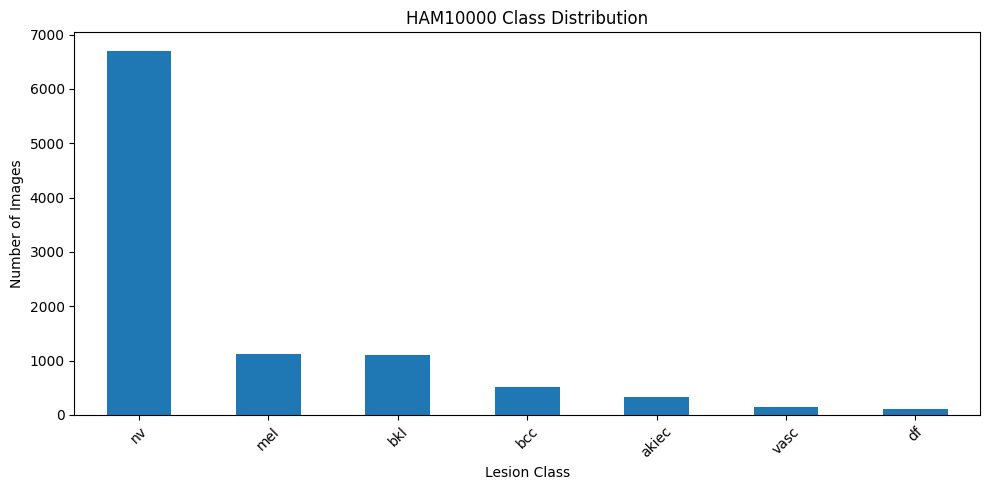

In [8]:
# Visualize class distribution

plt.figure(figsize=(10, 5))
df["dx"].value_counts().plot(kind="bar")
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Find all image files

HAM10000 is commonly distributed in two image folders.

We create one dictionary:

`image_id → image_path`

This lets us locate an image using its `image_id` from the metadata.


In [9]:
image_paths = {}

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_id = os.path.splitext(file)[0]
            image_paths[image_id] = os.path.join(root, file)

print("Total image files found:", len(image_paths))

# Add full path to the dataframe
df["image_path"] = df["image_id"].map(image_paths)

print("Images with valid paths:", df["image_path"].notna().sum())
print("Images without paths:", df["image_path"].isna().sum())

df = df.dropna(subset=["image_path"]).reset_index(drop=True)


Total image files found: 10015
Images with valid paths: 10015
Images without paths: 0


## 7. Look at sample images

Before training a CNN, students should always look at the data.

This helps us understand what the model is actually seeing.


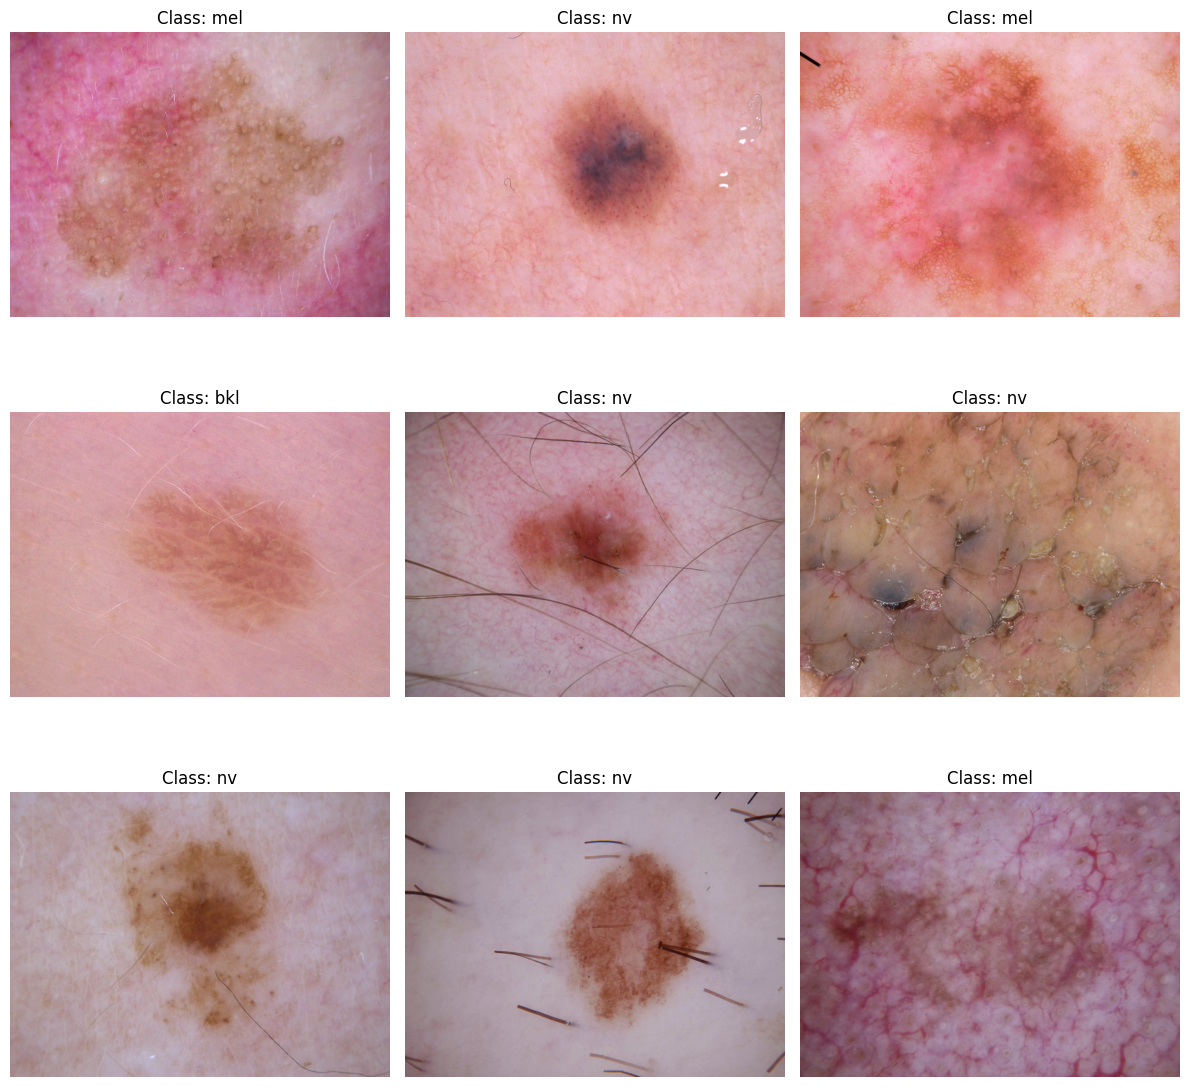

In [10]:
# Display a few random images

sample_df = df.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")

    ax = plt.subplot(3, 3, i + 1)
    ax.imshow(img)
    ax.set_title(f"Class: {row['dx']}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 8. Convert labels into numbers

Neural networks work with numerical labels.

For example:

```text
akiec → 0
bcc   → 1
bkl   → 2
...
```

The exact numbers are assigned automatically by `LabelEncoder`.


In [11]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class mapping:")

for i, name in enumerate(class_names):
    print(i, "→", name)


Number of classes: 7
Class mapping:
0 → akiec
1 → bcc
2 → bkl
3 → df
4 → mel
5 → nv
6 → vasc


## 9. Split into training and validation data

We use:

- **80% training data** → model learns from these images
- **20% validation data** → model is tested on images it did not use for weight updates

We use a **stratified split**, so the class proportions are approximately maintained in both sets.


In [12]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))


Training images: 8012
Validation images: 2003


In [13]:
# Compare class distributions

print("Training distribution:")
display(train_df["dx"].value_counts())

print("\nValidation distribution:")
display(val_df["dx"].value_counts())


Training distribution:


,count
dx,
nv,5364
mel,890
bkl,879
bcc,411
akiec,262
vasc,114
df,92



Validation distribution:


,count
dx,
nv,1341
mel,223
bkl,220
bcc,103
akiec,65
vasc,28
df,23


## 10. Create TensorFlow datasets

EfficientNet-B0 expects images with a fixed size.

We will resize all images to:

**224 × 224**

Batch size = **32**

`tf.data` helps us load images efficiently during training.


In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # EfficientNet preprocessing is included in the Keras EfficientNet model,
    # so we keep pixel values in the normal image range here.
    image = tf.cast(image, tf.float32)

    return image, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)

print("Datasets created.")


Datasets created.


## 11. Add data augmentation

Medical images can have small variations in:

- orientation
- zoom
- brightness
- position

Data augmentation creates slightly different versions of training images.

**Important:** We apply augmentation to training images, not validation images.


In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")


## 12. Build EfficientNet-B0

We start with **ImageNet pretrained weights**.

Why?

Instead of learning basic features such as edges and textures from zero, the model starts with useful visual features learned from a large image dataset.

Initially, we freeze the EfficientNet backbone.

So students can understand the idea of **transfer learning**.


In [16]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 13. Compile the model

We use:

### Loss
`SparseCategoricalCrossentropy`

Because this is a multi-class classification problem and our labels are integers.

### Optimizer
`Adam`

### Metric
`Accuracy`

The most important values we will watch are:

- Training loss
- Validation loss
- Training accuracy
- Validation accuracy


In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled.")


Model compiled.


## 14. Train the model

For classroom demonstration, start with **5 epochs**.

You can increase this later.

During every epoch, Keras reports:

```text
loss
accuracy
val_loss
val_accuracy
```

These values help us understand whether the model is learning.


In [18]:
EPOCHS = 5

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 851s 3s/step - accuracy: 0.6860 - loss: 0.9347 - val_accuracy: 0.6980 - val_loss: 0.8050 - learning_rate: 0.0010
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 863s 3s/step - accuracy: 0.7184 - loss: 0.7711 - val_accuracy: 0.7229 - val_loss: 0.7436 - learning_rate: 0.0010
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 908s 4s/step - accuracy: 0.7335 - loss: 0.7210 - val_accuracy: 0.7319 - val_loss: 0.7341 - learning_rate: 0.0010
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 881s 4s/step - accuracy: 0.7409 - loss: 0.6988 - val_accuracy: 0.7419 - val_loss: 0.7098 - learning_rate: 0.0010
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 883s 4s/step - accuracy: 0.7498 - loss: 0.6840 - val_accuracy: 0.7429 - val_loss: 0.6806 - learning_rate: 0.0010


# 15. Understanding Training Loss vs Validation Loss


### Training loss

Measures how wrong the model is on the training images.

We generally want:

**Training loss ↓**

### Validation loss

Measures how wrong the model is on unseen validation images.

We also generally want:

**Validation loss ↓**

### What does overfitting look like?

Suppose:

Training loss     ↓ ↓ ↓ ↓
Validation loss   ↓ ↓ ↑ ↑

The model is becoming better at memorizing training images, but its performance on unseen images is getting worse.

That is a classic sign of **overfitting**.


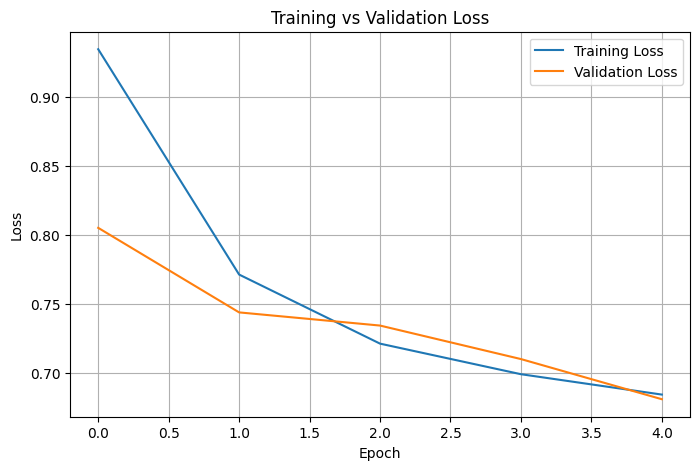

In [19]:
# Plot training and validation loss

history_dict = history.history

plt.figure(figsize=(8, 5))

plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# 16. Training Accuracy vs Validation Accuracy

### Training accuracy

How many training images the model classifies correctly.

### Validation accuracy

How many unseen validation images the model classifies correctly.

Ideally:


Training accuracy    ↑
Validation accuracy  ↑


and the two curves should remain reasonably close.

A very large gap can indicate overfitting.


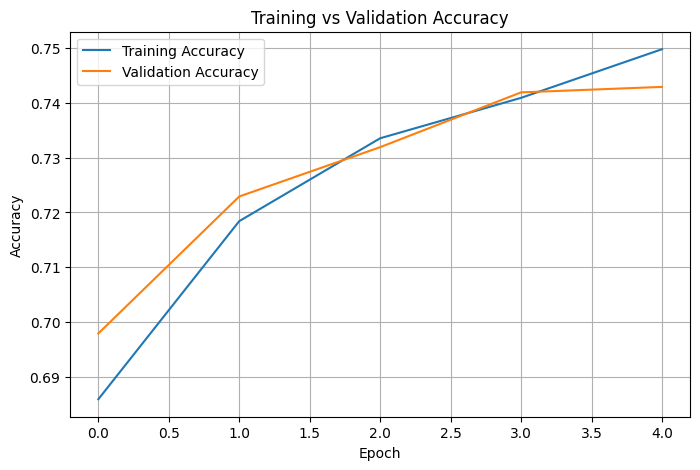

In [20]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# 17. Evaluate on validation data

After training, we calculate the final validation loss and accuracy.


In [21]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


63/63 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.7429 - loss: 0.6806
Validation Loss: 0.6806
Validation Accuracy: 0.7429
Validation Accuracy: 74.29%


# 18. Optional: Fine-tuning

 unfreeze part of EfficientNet-B0 and train with a **very small learning rate**.

This is called **fine-tuning**.

The idea is:


Stage 1:
Pretrained EfficientNet frozen
        ↓
Train classification head

Stage 2:
Unfreeze some EfficientNet layers
        ↓
Train with small learning rate
        ↓
Adapt features to skin-lesion images






### Question 1
Is training loss decreasing?

**If yes:** the model is learning from the training data.

### Question 2
Is validation loss decreasing?

**If yes:** the model is generally improving on unseen data.

### Question 3
Is training accuracy much higher than validation accuracy?

**If yes:** there may be overfitting.

### Question 4
Are both training and validation accuracies low?

Possible causes include:

- insufficient training
- difficult classification problem
- poor preprocessing
- model not learning enough useful features

### Question 5
Why don't we judge the model only using training accuracy?

Because the real goal is to perform well on **unseen images**, not just images the model has already learned from.

---

## The key lesson

> **A good model is not simply one that gets high training accuracy. We want good validation performance too.**

For this project, EfficientNet-B0 provides the image-classification architecture, while the loss and accuracy curves help us understand **how the model is learning and whether it is generalizing**.
